In [ ]:
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from scipy.sparse.linalg import expm_multiply

#### Transverse field Ising model

${\hat H} = -J \sum_{\langle i,j \rangle} \sigma^z_i \sigma^z_j - h_x  \sum_i \sigma^x_i- h_z\sum_i {\sigma}^z_i$

#### Heisenberg Hamiltonian in tranverse field Ising model

${\hat H} = J \sum_{\langle i,j \rangle} {\hat S}_i {\hat S}_j - h_x  \sum_i {\hat S}^x_i- h_z\sum_i {\hat S}^z_i$

- We want to solve the eigenvalue problem:
\begin{equation}
H \ket{\phi_n} = E_n \ket{\phi_n}.
\end{equation}

- The time evolution operator 

\begin{equation}
U(t) = e^{-i H t},
\end{equation}

- and real-time evolution in a quantum sate
\begin{equation}
\ket{\psi(t)} = 
\sum_n e^{-i E_n t} 
\braket{\phi_n | \psi(0)} \ket{\phi_n}.
\end{equation}

-  Observables:  Local Magnetization

\begin{equation}
\langle \sigma_i^z \rangle(t)
=
\sum_s |\psi_s(t)|^2 \, s_i^z .
\end{equation}

\begin{equation}
\langle \sigma_i^x \rangle(t)
=
\sum_s 
\psi_s^*(t) \,
\psi_{s \oplus 2^i}(t).
\end{equation}

-  Two-Point Correlation

\begin{equation}
C_{ij}^{zz}(t)
=
\langle \sigma_i^z \sigma_j^z \rangle (t)
=
\sum_s |\psi_s(t)|^2 \, s_i^z s_j^z .
\end{equation}

-   Entanglement Entropy: We divide the lattice into a subsystem $A$ and its complement $B$.

- Reduced Density Matrix

\begin{equation}
\rho_A = \mathrm{Tr}_B \, \ket{\psi}\bra{\psi}.
\end{equation}

-  von Neumann Entropy

\begin{equation}
S_{\mathrm{vN}}(A)
=
-\mathrm{Tr}(\rho_A \log \rho_A).
\end{equation}

-  Rényi-$\alpha$ Entropy

\begin{equation}
S_\alpha(A)
=
\frac{1}{1-\alpha}
\log \mathrm{Tr}(\rho_A^\alpha).
\end{equation}

In this work, we frequently use $\alpha = 2$:
\begin{equation}
S_2(A) = -\log \mathrm{Tr}(\rho_A^2).
\end{equation}




- Entanglement entropies in DMRG

- Rényi entropies

$$
S_\alpha = \frac{1}{1-\alpha}\,\log\!\left(\mathrm{Tr}\,\rho^\alpha\right)
$$

- Neumann entropy

$$
S_{\mathrm{vN}} = -\mathrm{Tr}(\rho \log \rho).
$$



- The von Neumann entanglement entropy is $$ S_{\mathrm{vN}} = -\sum_{i} \lambda_i \,\log \lambda_i .$$

---

 Advantages of Rényi entropies

1. **Easy to compute:**  
   If the reduced density matrix has eigenvalues $\{\lambda_i\}$,

   $$
   S_\alpha = \frac{1}{1-\alpha}\log\!\left(\sum_i \lambda_i^\alpha\right).
   $$

2. **Useful for scaling:**  
   Rényi entropies often simplify finite-entanglement or finite-size scaling, and extraction of CFT central charge.

3. **Probe different parts of the spectrum:**  
   - small $\alpha$: sensitive to many small eigenvalues  
   - large $\alpha>1$: dominated by largest eigenvalues

---





## Exact diagonalization code for Heisenberg and transverse field Ising model 

- Time evolution for the transverse field Ising model

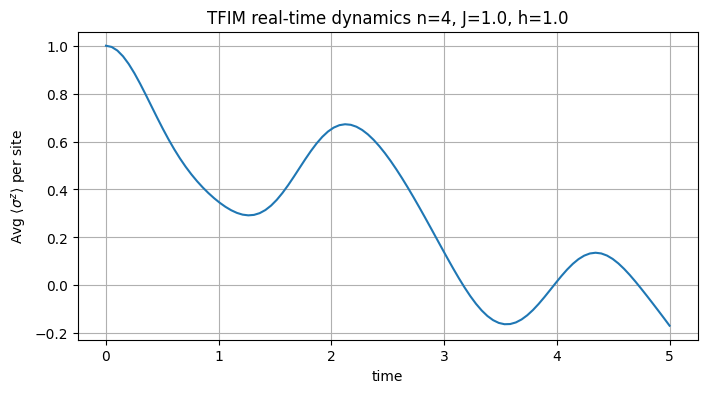

Lowest 8 eigenvalues:
[-5.22625186e+00 -4.82842712e+00 -2.16478440e+00 -2.00000000e+00
 -2.00000000e+00 -8.28427125e-01 -2.66453526e-15 -1.48902501e-16]


In [ ]:
def all_basis_states(n, conserve_sz=False, nup=None):
    N = 1 << n
    states = []
    for s in range(N):
        if conserve_sz:
            if nup is None:
                raise ValueError("nup must be provided when conserve_sz=True")
            if bin(s).count("1") != nup:
                continue
        states.append(s)
    idx = {s: i for i, s in enumerate(states)}
    return np.array(states, dtype=int), idx

def heisenberg_hamiltonian(n, J=1.0, periodic=True, conserve_sz=False, nup=None):
    states, idx = all_basis_states(n, conserve_sz=conserve_sz, nup=nup)
    dim = len(states)
    H = np.zeros((dim, dim), dtype=np.float64)
    for k, s in enumerate(states):
        for bond in range(n if periodic else n-1):
            j = (bond + 1) % n
            site1 = 1 << bond
            site2 = 1 << j
            di = site1 | site2
            da = s & di
            if da == di or da == 0:
                H[k, k] += 0.25 * J
            else:
                H[k, k] += -0.25 * J
                s2 = s ^ di
                if s2 in idx:
                    H[idx[s2], k] += 0.5 * J
    return H, states, idx

def tfim_hamiltonian(n, J=1.0, h=1.0, periodic=True, conserve_sz=False, nup=None):
    states, idx = all_basis_states(n, conserve_sz=conserve_sz, nup=nup)
    dim = len(states)
    H = np.zeros((dim, dim), dtype=np.float64)
    for k, s in enumerate(states):
        for bond in range(n if periodic else n-1):
            j = (bond + 1) % n
            bit1 = 1 if (s >> bond) & 1 else -1
            bit2 = 1 if (s >> j) & 1 else -1
            H[k, k] += -J * (bit1 * bit2)
        for site in range(n):
            s2 = s ^ (1 << site)
            if s2 in idx:
                H[idx[s2], k] += -h
    return H, states, idx

def diagonalize(H):
    vals, vecs = eigh(H)
    return vals, vecs

def time_evolution_operator_from_eig(vals, vecs):
    def evolve(psi0, t):
        phases = np.exp(-1j * vals * t)
        coeffs = vecs.conj().T @ psi0
        coeffs_t = coeffs * phases
        psi_t = vecs @ coeffs_t
        return psi_t
    return evolve

def expectation_sigma_z_total(psi, n, states):
    exp = 0.0 + 0.0j
    for amp, s in zip(psi, states):
        mz = 0
        for site in range(n):
            mz += (1 if ((s >> site) & 1) else -1)
        exp += (np.abs(amp)**2) * mz
    return exp.real

def product_state_z(n, up=True):
    return (1 << n) - 1 if up else 0

def basis_state_vector(index_in_states, dim):
    v = np.zeros(dim, dtype=complex)
    v[index_in_states] = 1.0 + 0.0j
    return v

# Dynamics of a transverse field Ising model
if __name__ =='__main__':
    n = 4
    J = 1.0
    h = 1.0
    periodic = True

    H_tfim, states_tfim, idx_tfim = tfim_hamiltonian(n, J=J, h=h, periodic=periodic, conserve_sz=False)
    vals, vecs = diagonalize(H_tfim)
    evolver = time_evolution_operator_from_eig(vals, vecs)

    s0 = product_state_z(n, up=True)
    idx0 = int(np.where(states_tfim == s0)[0][0])
    psi0 = basis_state_vector(idx0, len(states_tfim))

    tmax = 5.0#10.0
    nt = 100#201
    times = np.linspace(0, tmax, nt)
    mz_t = np.zeros_like(times, dtype=float)

    for i, t in enumerate(times):
        psi_t = evolver(psi0, t)
        mz = expectation_sigma_z_total(psi_t, n, states_tfim) / n
        mz_t[i] = mz

    plt.figure(figsize=(8,4))
    plt.plot(times, mz_t)
    plt.xlabel("time")
    plt.ylabel(r"Avg $\langle \sigma^z \rangle$ per site")
    plt.title(f"TFIM real-time dynamics n={n}, J={J}, h={h}")
    plt.grid(True)
    plt.show()

    print("Lowest 8 eigenvalues:")
    print(vals[:8])


- Exact diagonalization for triangular lattice model

In [ ]:

# ================================================================
#  Basis generation
# ================================================================
def all_basis_states(n):
    """
    Full 2^n basis for spin-1/2 system in Z basis.
    """
    states = np.arange(1 << n, dtype=int)
    idx = {s: i for i, s in enumerate(states)}
    return states, idx


# ================================================================
#  Triangular lattice bond generator (fully periodic L×L lattice)
# ================================================================
def triangular_lattice_bonds_LxL(L):
    """
    Return nearest-neighbor bonds for a fully periodic
    triangular lattice of size LxL (N = L^2).
    Coordinates:
       (x, y), with x=0..L−1, y=0..L−1
    Neighbors:
       (x+1, y)
       (x, y+1)
       (x+1, y-1)
    all modulo L.
    """
    bonds = []
    for x in range(L):
        for y in range(L):
            i = x + L * y
            # right
            j = ((x + 1) % L) + L * y
            bonds.append((i, j))
            # up
            j = x + L * ((y + 1) % L)
            bonds.append((i, j))
            # diagonal up-right
            j = ((x + 1) % L) + L * ((y - 1) % L)
            bonds.append((i, j))
    return bonds


# ================================================================
#  General Ising Hamiltonian on arbitrary graph
# ================================================================
def triangular_ising_hamiltonian(
        n,
        bonds,
        J=1.0,
        hx=0.0,
        hz=0.0
    ):
    """
    Construct the Hamiltonian:

       H = -J Σ σ^z_i σ^z_j - hx Σ σ^x_i - hz Σ σ^z_i

    for a system with 'n' spins and a list of nearest-neighbor
    bonds defining the triangular lattice.

    bonds = [(i,j), ...] list of integer pairs
    """
    states, idx = all_basis_states(n)
    dim = len(states)

    H = np.zeros((dim, dim), dtype=np.float64)

    # --------------------------------
    #  Z-Z interactions
    # --------------------------------
    for (i, j) in bonds:
        for k, s in enumerate(states):

            si = 1 if ((s >> i) & 1) else -1
            sj = 1 if ((s >> j) & 1) else -1

            H[k, k] += -J * si * sj

    # --------------------------------
    #  Longitudinal field h_z
    # --------------------------------
    if hz != 0.0:
        for k, s in enumerate(states):
            mz = 0
            for i in range(n):
                mz += (1 if ((s >> i) & 1) else -1)
            H[k, k] += -hz * mz

    # --------------------------------
    #  Transverse field h_x (spin flip)
    # --------------------------------
    if hx != 0.0:
        for k, s in enumerate(states):
            for i in range(n):
                s2 = s ^ (1 << i)  # flip spin i
                H[idx[s2], k] += -hx

    return H, states, idx


# ================================================================
#  ED: Diagonalize Hamiltonian
# ================================================================
def diagonalize(H):
    vals, vecs = eigh(H)
    return vals, vecs


# ================================================================
#  Time evolution via eigen-decomposition
# ================================================================
def time_evolution_operator(vals, vecs):
    """
    Return function evolve(psi0, t).
    """
    def evolve(psi0, t):
        phases = np.exp(-1j * vals * t)
        c = vecs.conj().T @ psi0
        psi_t = vecs @ (phases * c)
        return psi_t

    return evolve


# ================================================================
#  Utility: basis vector
# ================================================================
def basis_vector(index, dim):
    v = np.zeros(dim, dtype=complex)
    v[index] = 1.0 + 0.0j
    return v


# ================================================================
#   clusters: 6, 9, 12 sites triangular tori
# ================================================================
def triangular_cluster_bonds(N):
    """
    Provide bonds for specific ED-friendly fully periodic clusters:
    N = 6, 9, 12
    (standard clusters used in frustrated-magnetism literature)

    NOTE:
      These are manually optimized clusters.
      Modify or add more as needed.
    """

    if N == 6:
        # Hexagon with full periodicity 
        # Bonds given as nearest neighbors
        bonds = [
            (0,1),(1,2),(2,3),(3,4),(4,5),(5,0),  # ring
            (0,2),(1,3),(2,4),(3,5),(4,0),(5,1)   # diagonals 
        ]
        return bonds

    if N == 9:
        # 3x3 triangular fully periodic
        return triangular_lattice_bonds_LxL(3)

    if N == 12:
        # 4x3 fully periodic triangular cluster
        Lx = 4
        Ly = 3
        bonds=[]
        for x in range(Lx):
            for y in range(Ly):
                i = x + Lx * y
                # right
                j = ((x+1)%Lx) + Lx*y
                bonds.append((i,j))
                # up
                j = x + Lx*((y+1)%Ly)
                bonds.append((i,j))
                # diag up-right
                j = ((x+1)%Lx) + Lx*((y-1)%Ly)
                bonds.append((i,j))
        return bonds

    raise ValueError(f"No predefined cluster for N={N}. Add one or use L×L generator.")


# ================================================================
# ================================================================
if __name__ == "__main__":

    N = 6
    bonds = triangular_cluster_bonds(N)

    J = 1.0
    hx = 0.5
    hz = 0.3

    H, states, idx = triangular_ising_hamiltonian(
        N, bonds, J=J, hx=hx, hz=hz
    )

    vals, vecs = diagonalize(H)

    # Example initial state: |000...0>
    psi0 = basis_vector(0, len(states))

    evolve = time_evolution_operator(vals, vecs)

    # evolve to time t=1.0 (example)
    psi_t = evolve(psi0, 1.0)

    print("Lowest eigenvalues:")
    print(vals[:8])


Lowest eigenvalues:
[-13.974545   -10.40316046  -5.52407351  -5.41878496  -5.41878496
  -5.41878496  -5.36647468  -5.36647468]


- Triangular lattice Exact Diagonalizations
- Time evolutions 
- Reny Von Neuman entropies

In [ ]:


# ============================================================
#  Utilities: Basis
# ============================================================
def all_states(n):
    states = np.arange(1<<n, dtype=np.int64)
    idx = {s:i for i,s in enumerate(states)}
    return states, idx


# ============================================================
#  Triangular lattice bonds
# ============================================================
def triangular_LxL_bonds(L):
    bonds = []
    for x in range(L):
        for y in range(L):
            i = x + L*y

            bonds.append((i, ((x+1)%L) + L*y))             # → right
            bonds.append((i, x + L*((y+1)%L)))             # ↑ up
            bonds.append((i, ((x+1)%L) + L*((y-1)%L)))     # diagonal
    return bonds


def triangular_cluster_bonds(N):
    """Common ED clusters."""
    if N == 6:
        return [
            (0,1),(1,2),(2,3),(3,4),(4,5),(5,0),
            (0,2),(1,3),(2,4),(3,5),(4,0),(5,1)
        ]
    if N == 9:
        return triangular_LxL_bonds(3)
    if N == 12:
        Lx=4; Ly=3
        bonds=[]
        for x in range(Lx):
            for y in range(Ly):
                i = x + Lx*y
                bonds.append((i, ((x+1)%Lx)+Lx*y))
                bonds.append((i, x + Lx*((y+1)%Ly)))
                bonds.append((i, ((x+1)%Lx) + Lx*((y-1)%Ly)))
        return bonds

    raise ValueError("Add definition for cluster with N = {}".format(N))


# ============================================================
#  Hamiltonian: Triangular Ising Model
# ============================================================
def triangular_ising_hamiltonian(n, bonds, J=1.0, hx=0.0, hz=0.0):
    states, idx = all_states(n)
    dim = len(states)

    H = np.zeros((dim, dim), dtype=np.float64)

    # ZZ terms
    for i,j in bonds:
        for k,s in enumerate(states):
            si = 1 if ((s>>i)&1) else -1
            sj = 1 if ((s>>j)&1) else -1
            H[k,k] += -J * si * sj

    # h_z Σ σ^z
    if hz != 0:
        for k,s in enumerate(states):
            mz = 0
            for i in range(n):
                mz += (1 if ((s>>i)&1) else -1)
            H[k,k] += -hz * mz

    # h_x Σ σ^x : spin flip
    if hx != 0:
        for k,s in enumerate(states):
            for i in range(n):
                s2 = s ^ (1<<i)
                H[idx[s2], k] += -hx

    return H, states, idx


# ============================================================
#  ED Diagonalization
# ============================================================
def diagonalize(H):
    vals, vecs = eigh(H)
    return vals, vecs


# ============================================================
#  Time evolution
# ============================================================
def time_evolution_exact(vals, vecs):
    def evolve(psi0, t):
        phases = np.exp(-1j * vals * t)
        c = vecs.conj().T @ psi0
        return vecs @ (phases * c)
    return evolve


def time_evolution_krylov(H):
    """Sparse-friendly evolution: psi(t)=e^{-iHt} psi."""
    def evolve(psi0, t):
        return expm_multiply(-1j*H, psi0, start=0, stop=t, num=2)[-1]
    return evolve


# ============================================================
#  Observables
# ============================================================
def sigma_z_i(psi, i, states):
    exp = 0.0
    for amp, s in zip(psi, states):
        sz = 1 if ((s>>i)&1) else -1
        exp += np.abs(amp)**2 * sz
    return exp


def sigma_x_i(psi, i, states, idx):
    exp = 0.0
    for k, s in enumerate(states):
        s2 = s ^ (1<<i)
        exp += np.conj(psi[k]) * psi[idx[s2]]
    return 2*exp.real   # <σx> = <↑|↓>+<↓|↑>


def sigma_z_z(i, j, psi, states):
    exp = 0.0
    for amp, s in zip(psi, states):
        si = 1 if ((s>>i)&1) else -1
        sj = 1 if ((s>>j)&1) else -1
        exp += np.abs(amp)**2 * si * sj
    return exp


# ============================================================
#  Entanglement (Rényi & von Neumann)
# ============================================================
def reduced_density_matrix(psi, n, A):
    """
    Subsystem A: list of sites
    Subsystem B: complement
    psi is state vector in computational basis.
    Construct ρ_A by reshaping state into tensor.
    """
    A = list(A)
    B = [i for i in range(n) if i not in A]
    NA = len(A)
    NB = len(B)

    rho_shape = (2,)*n
    psi_tensor = psi.reshape(rho_shape)

    # Trace out B
    for b in sorted(B, reverse=True):
        psi_tensor = np.trace(psi_tensor, axis1=b, axis2=b)

    # Final subsystem Hilbert dim
    dimA = 1 << NA
    return psi_tensor.reshape((dimA, dimA))


def von_neumann_entropy(psi, n, A):
    rhoA = reduced_density_matrix(psi, n, A)
    vals = np.linalg.eigvalsh(rhoA)
    vals = vals[vals > 1e-15]
    return -np.sum(vals * np.log(vals))


def renyi_entropy(psi, n, A, alpha=2):
    if alpha == 1:
        return von_neumann_entropy(psi, n, A)
    rhoA = reduced_density_matrix(psi, n, A)
    vals = np.linalg.eigvalsh(rhoA)
    vals = vals[vals > 1e-15]
    return 1/(1-alpha) * np.log(np.sum(vals**alpha))


# ============================================================
#  Basis  |state_index>
# ============================================================
def basis_state(idx, dim):
    v = np.zeros(dim, dtype=complex)
    v[idx] = 1.0
    return v


# ============================================================
if __name__ == "__main__":

    N = 6
    bonds = triangular_cluster_bonds(N)

    J = 1.0
    hx = 0.5
    hz = 0.2

    H, states, idx = triangular_ising_hamiltonian(N, bonds, J, hx, hz)

    vals, vecs = diagonalize(H)
    evolve = time_evolution_exact(vals, vecs)

    psi0 = basis_state(0, len(states))  # |↓↓...↓↓>

    psi_t = evolve(psi0, 1.0)

    print("Lowest eigenvalues:", vals[:6])
    print("⟨σ^z_0⟩ =", sigma_z_i(psi_t, 0, states))
    print("Rényi-2 entropy of first half:", renyi_entropy(psi_t, N, A=range(N//2), alpha=2))
